# Architecture 3 v3 — Prompt Profiling Pipeline (Final)

**Improvements over v2:**
1. **Augmented Dataset** — 615 prompts (vs 470): +45 vague T2, +20 D5=1.0, +30 boundary, +15 D4-explicit T3
2. **D4 via ML** — Trained as 5th XGBClassifier output instead of keyword rule engine
3. **Two-Stage Prediction** — Direct tier classifier + dimension classifiers with tier as feature
4. **5-Fold Cross-Validation** — Robust evaluation, all data used for train+test
5. **30 PCA Components** — Tighter dimensionality reduction (was 50)
6. **25 Hand-Crafted Features** — 7 new D4/boundary-targeting features
7. **Regularized XGBoost** — L1/L2 regularization + class weights

**Pipeline:**  
```
Prompt → MiniLM-L6-v2 (384d) → PCA (30d) + Hand-Crafted (25d) = 55 features
  Stage 1: features → XGBClassifier → Tier prediction
  Stage 2: features + tier_pred → MultiOutputClassifier(XGBClassifier) → D1–D5
  Stage 3: Ensemble tier (Stage 1 vote + Stage 2 derived tier)
```

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

print("All imports successful.")

All imports successful.


---
## Helper Functions

In [2]:
# ── Score <-> Class mappings ──────────────────────────────────────────────────
SCORE_TO_CLASS = {0.0: 0, 0.25: 1, 0.50: 2, 0.75: 3, 1.0: 4}
CLASS_TO_SCORE = {0: 0.0, 1: 0.25, 2: 0.50, 3: 0.75, 4: 1.0}
TIER_TO_INT = {'T1': 0, 'T2': 1, 'T3': 2}
INT_TO_TIER = {0: 'T1', 1: 'T2', 2: 'T3'}


def complexity_score(d1, d2, d3, d4, d5):
    """Compute weighted complexity score."""
    return (d1 * 0.35) + (d2 * 0.20) + (d3 * 0.20) + (d4 * 0.15) + (d5 * 0.10)


def get_tier(score):
    """Map complexity score to tier."""
    if score < 0.40:
        return 'T1'
    elif score < 0.70:
        return 'T2'
    else:
        return 'T3'


# Sanity checks
assert get_tier(0.10) == 'T1'
assert get_tier(0.55) == 'T2'
assert get_tier(0.85) == 'T3'
print("Helper functions verified.")

Helper functions verified.


In [3]:
def extract_handcrafted_features(prompt, phrasing_style=None):
    """Extract 25 structural/linguistic features from a prompt.

    v3 adds 7 new features vs v2 (18 → 25):
    - D4-specific: external_data_keyword_score, has_time_reference,
      vendor_tool_count, has_cost_comparison
    - Boundary-targeting: stakeholder_mentions, risk_language, action_verb_count
    """
    text = prompt.lower()
    words = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

    features = {
        # ── Text statistics (6) ───────────────────────────────────────────
        'word_count': len(words),
        'char_count': len(text),
        'sentence_count': max(len(sentences), 1),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'question_marks': text.count('?'),
        'comma_count': text.count(','),

        # ── Attachment / context → D2, D5 (1) ─────────────────────────────
        'has_attachment': int(any(kw in text for kw in [
            'attached', 'uploaded', 'pasted', 'screenshot',
            "i've attached", 'i have uploaded', "i've uploaded",
            'the attached', 'file attached'
        ])),

        # ── Comparison → D3 (1) ───────────────────────────────────────────
        'has_comparison': int(any(kw in text for kw in [
            ' vs ', 'versus', 'compare', 'comparison',
            'difference between', 'differ', 'comparing'
        ])),

        # ── Compliance → T3 (1) ───────────────────────────────────────────
        'has_compliance': int(any(kw in text for kw in [
            'nist', 'hipaa', 'gdpr', 'soc 2', 'soc2',
            'iso 27001', 'iso27001', 'iso/iec', 'pci dss',
            'eu ai act', 'ccpa', 'cpra', 'fcra', 'eeoc',
            'reach', 'cbam', 'annex'
        ])),

        # ── Multi-cloud → D3 (1) ──────────────────────────────────────────
        'cloud_providers_mentioned': sum(
            1 for kw in ['aws', 'azure', 'gcp', 'google cloud'] if kw in text
        ),

        # ── Multi-system → D3 (1) ─────────────────────────────────────────
        'systems_mentioned': sum(
            1 for kw in [
                'salesforce', 'sap', 'workday', 'hubspot', 'jira',
                'servicenow', 'okta', 'terraform', 'kubernetes',
                'kafka', 'snowflake', 'databricks', 'mulesoft',
                'openai', 'anthropic', 'bedrock', 'sagemaker'
            ] if kw in text
        ),

        # ── Deliverable → D1, D5 (1) ──────────────────────────────────────
        'has_deliverable': int(any(kw in text for kw in [
            'roadmap', 'framework', 'architecture', 'specification',
            'policy', 'checklist', 'runbook', 'report', 'proposal',
            'strategy', 'plan', 'document', 'guide', 'matrix',
            'blueprint', 'playbook'
        ])),

        # ── Scope → D1 (1) ────────────────────────────────────────────────
        'has_scope_words': int(any(kw in text for kw in [
            'comprehensive', 'end-to-end', 'full', 'complete',
            'detailed', 'entire', 'step-by-step', 'formal'
        ])),

        # ── Market terms → D4 (1) ─────────────────────────────────────────
        'has_market_terms': int(any(kw in text for kw in [
            'market', 'pricing', 'vendor', 'competitor',
            'benchmark', 'industry', 'gartner', 'cost of'
        ])),

        # ── Phrasing style (3) ────────────────────────────────────────────
        'phrasing_explicit': 0,
        'phrasing_implicit': 0,
        'phrasing_vague': 0,

        # ══ NEW v3 FEATURES (7) ══════════════════════════════════════════

        # ── D4: External data keyword density (0-1 scale) ─────────────────
        'external_data_score': min(1.0, sum(
            1 for kw in [
                'market research', 'competitive analysis', 'analyst report',
                'industry trends', 'industry report', 'industry benchmark',
                'latest pricing', 'current pricing', 'current market',
                'vendor pricing', 'vendor comparison', 'compare vendors',
                'real-time pricing', 'pricing models', 'pricing tiers',
                'competitor', 'survey data', 'salary survey',
                'gartner', 'forrester', 'mckinsey', 'flexera',
                'benchmark data', 'industry peers', 'market rates'
            ] if kw in text
        ) / 3.0),

        # ── D4: Time sensitivity references ───────────────────────────────
        'has_time_reference': int(any(kw in text for kw in [
            'this quarter', 'this month', 'last quarter', 'last month',
            'next quarter', 'next month', 'this year', 'fiscal year',
            'current rates', 'latest', 'recent', 'real-time',
            'current state', 'today'
        ])),

        # ── D4: Vendor/tool name count ────────────────────────────────────
        'vendor_tool_count': sum(
            1 for kw in [
                'openai', 'anthropic', 'cohere', 'google', 'microsoft',
                'stripe', 'twilio', 'segment', 'tealium', 'mparticle',
                'sailpoint', 'saviynt', 'cyberark', 'checkr', 'sterling',
                'sift', 'forter', 'locus', 'fetch robotics',
                'mulesoft', 'boomi', 'backstage', 'cortex',
                'splunk', 'datadog', 'pagerduty', 'sonarqube'
            ] if kw in text
        ),

        # ── D4: Cost/price comparison signals ─────────────────────────────
        'has_cost_comparison': int(any(kw in text for kw in [
            'cost comparison', 'price comparison', 'total cost of ownership',
            'tco', 'roi projection', 'cost-benefit', 'cost benefit',
            'cheaper', 'cost savings', 'pay bands', 'compensation bench'
        ])),

        # ── Boundary: Stakeholder mentions → T3 signal ────────────────────
        'stakeholder_mentions': sum(
            1 for kw in [
                'ceo', 'cto', 'cfo', 'ciso', 'cmo',
                'board', 'executive', 'leadership', 'director',
                'vp of', 'vice president'
            ] if kw in text
        ),

        # ── Boundary: Risk/legal language → T3 signal ─────────────────────
        'risk_language': int(any(kw in text for kw in [
            'liability', 'exposure', 'penalty', 'breach', 'violation',
            'lawsuit', 'audit', 'regulatory', 'compliance gap',
            'risk assessment', 'risk posture', 'remediation'
        ])),

        # ── Boundary: Action verb count → scope indicator ─────────────────
        'action_verb_count': sum(
            1 for kw in [
                'build', 'design', 'evaluate', 'draft', 'develop',
                'create', 'produce', 'generate', 'implement',
                'establish', 'restructure', 'migrate', 'optimize'
            ] if kw in text
        ),
    }

    # One-hot encode phrasing style
    if phrasing_style:
        style = phrasing_style.lower().strip()
        if style == 'explicit':
            features['phrasing_explicit'] = 1
        elif style == 'implicit':
            features['phrasing_implicit'] = 1
        elif style == 'vague':
            features['phrasing_vague'] = 1

    return features


# Quick test
test_feats = extract_handcrafted_features(
    "Research the current market pricing for AWS and Azure GPU instances from Gartner benchmarks and produce a cost comparison report for the CFO",
    phrasing_style="explicit"
)
print(f"Feature count: {len(test_feats)}")
print(f"D4-related: external_data_score={test_feats['external_data_score']:.2f}, "
      f"has_time_reference={test_feats['has_time_reference']}, "
      f"vendor_tool_count={test_feats['vendor_tool_count']}, "
      f"has_cost_comparison={test_feats['has_cost_comparison']}")
print(f"Boundary: stakeholder={test_feats['stakeholder_mentions']}, "
      f"risk={test_feats['risk_language']}, actions={test_feats['action_verb_count']}")

Feature count: 24
D4-related: external_data_score=0.67, has_time_reference=0, vendor_tool_count=0, has_cost_comparison=1
Boundary: stakeholder=1, risk=0, actions=1


---
## Step 1 — Load Augmented Dataset

In [4]:
# ── Load augmented CSV ────────────────────────────────────────────────────────
df = pd.read_csv('/content/dataset_prompt_profiling_v2.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nD5 value counts (now includes 1.0):")
print(df['d5'].value_counts().sort_index())
df.head()

Dataset shape: (615, 9)
Columns: ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5']

D5 value counts (now includes 1.0):
d5
0.00    184
0.25    217
0.50    139
0.75     55
1.00     20
Name: count, dtype: int64


,id,prompt,phrasing_style,domain,d1,d2,d3,d4,d5
0,day2_t1_gap_001,what does mqtt stand for and why do iot devices use it instead of http,explicit,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
1,day2_t1_gap_002,"the syslog file attached is showing error code 0x4F on the assembly arm PLC, what does that mean",implicit,IoT & Smart Factory,0.00,0.50,0.00,0.25,0.25
2,day2_t1_gap_003,modbus rtu vs modbus tcp what is the main difference,vague,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
3,day2_t1_gap_004,how do I reboot a generic smart sensor if it loses factory network connection,explicit,IoT & Smart Factory,0.00,0.25,0.25,0.00,0.00
4,day2_t1_gap_005,"our factory floor monitors are lagging compared to the control room, are we supposed to use webs...",implicit,IoT & Smart Factory,0.25,0.50,0.00,0.00,0.00


In [5]:
# ── Tier derivation ──────────────────────────────────────────────────────────
df['complexity_score'] = df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
df['tier'] = df['complexity_score'].apply(get_tier)

print(f"Tier distribution:")
print(df['tier'].value_counts().sort_index())
print(f"\nPhrasing style by tier:")
print(pd.crosstab(df['tier'], df['phrasing_style']))
print(f"\nTotal rows: {len(df)}")

Tier distribution:
tier
T1    208
T2    216
T3    191
Name: count, dtype: int64

Phrasing style by tier:
phrasing_style  explicit  implicit  vague
tier                                     
T1                    85        56     67
T2                    76        77     63
T3                    70        76     45

Total rows: 615


---
## Step 2 — Feature Engineering

### 2A: Sentence Embeddings → PCA (30d)
### 2B: Hand-Crafted Features (25d)
### Combined: 55 features

In [6]:
# ── 2A: Generate embeddings ──────────────────────────────────────────────────
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

prompts = df['prompt'].tolist()
embeddings = embed_model.encode(prompts, show_progress_bar=True, batch_size=64)
print(f"Raw embeddings: {embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Raw embeddings: (615, 384)


In [7]:
# ── 2B: Extract hand-crafted features ────────────────────────────────────────
hc_records = []
for _, row in df.iterrows():
    feats = extract_handcrafted_features(row['prompt'], row.get('phrasing_style'))
    hc_records.append(feats)

hc_df = pd.DataFrame(hc_records)
hc_features = hc_df.values
hc_feature_names = list(hc_df.columns)

print(f"Hand-crafted features: {hc_features.shape}")
print(f"Feature names ({len(hc_feature_names)}): {hc_feature_names}")

Hand-crafted features: (615, 24)
Feature names (24): ['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'question_marks', 'comma_count', 'has_attachment', 'has_comparison', 'has_compliance', 'cloud_providers_mentioned', 'systems_mentioned', 'has_deliverable', 'has_scope_words', 'has_market_terms', 'phrasing_explicit', 'phrasing_implicit', 'phrasing_vague', 'external_data_score', 'has_time_reference', 'vendor_tool_count', 'has_cost_comparison', 'stakeholder_mentions', 'risk_language', 'action_verb_count']


In [8]:
# ── Verify D4-specific features by tier ──────────────────────────────────────
hc_df['tier'] = df['tier'].values
print("New D4-specific feature means by tier:")
print(hc_df.groupby('tier')[[
    'external_data_score', 'has_time_reference',
    'vendor_tool_count', 'has_cost_comparison',
    'has_market_terms'
]].mean().round(3))
print("\nBoundary feature means by tier:")
print(hc_df.groupby('tier')[[
    'stakeholder_mentions', 'risk_language', 'action_verb_count'
]].mean().round(3))
hc_df.drop('tier', axis=1, inplace=True)

New D4-specific feature means by tier:
      external_data_score  has_time_reference  vendor_tool_count  \
tier                                                               
T1                  0.000               0.014              0.034   
T2                  0.002               0.093              0.097   
T3                  0.115               0.209              0.277   

      has_cost_comparison  has_market_terms  
tier                                         
T1                  0.010             0.019  
T2                  0.005             0.046  
T3                  0.052             0.382  

Boundary feature means by tier:
      stakeholder_mentions  risk_language  action_verb_count
tier                                                        
T1                   0.082          0.005              0.087
T2                   0.167          0.130              0.755
T3                   0.304          0.157              0.592


---
## Step 3 — Prepare Targets

**Key v3 change:** D4 is now an ML target (5th dimension), not rule-based.

In [9]:
# ── Prepare targets: ALL 5 dimensions via ML ─────────────────────────────────
target_cols = ['d1', 'd2', 'd3', 'd4', 'd5']  # D4 is now ML!
dim_names = ['D1', 'D2', 'D3', 'D4', 'D5']
y_scores = df[target_cols].values
y_classes = np.vectorize(SCORE_TO_CLASS.get)(y_scores).astype(int)

# Tier labels for stratification
tier_labels = df['tier'].values
tier_int = np.array([TIER_TO_INT[t] for t in tier_labels])

print(f"Targets: {target_cols} (all ML-predicted now)")
print(f"Target classes shape: {y_classes.shape}")
print(f"\nClass distribution per dimension:")
for i, dim in enumerate(dim_names):
    unique, counts = np.unique(y_classes[:, i], return_counts=True)
    print(f"  {dim}: {dict(zip(unique, counts))}")

Targets: ['d1', 'd2', 'd3', 'd4', 'd5'] (all ML-predicted now)
Target classes shape: (615, 5)

Class distribution per dimension:
  D1: {np.int64(0): np.int64(110), np.int64(1): np.int64(81), np.int64(2): np.int64(110), np.int64(3): np.int64(212), np.int64(4): np.int64(102)}
  D2: {np.int64(0): np.int64(23), np.int64(1): np.int64(130), np.int64(2): np.int64(204), np.int64(3): np.int64(166), np.int64(4): np.int64(92)}
  D3: {np.int64(0): np.int64(106), np.int64(1): np.int64(94), np.int64(2): np.int64(132), np.int64(3): np.int64(191), np.int64(4): np.int64(92)}
  D4: {np.int64(0): np.int64(305), np.int64(1): np.int64(115), np.int64(2): np.int64(28), np.int64(3): np.int64(107), np.int64(4): np.int64(60)}
  D5: {np.int64(0): np.int64(184), np.int64(1): np.int64(217), np.int64(2): np.int64(139), np.int64(3): np.int64(55), np.int64(4): np.int64(20)}


---
## Step 4 — 5-Fold Cross-Validation

**Two-stage prediction per fold:**
1. **Stage 1:** Train a direct tier classifier (features → tier)
2. **Stage 2:** Append Stage 1 tier prediction as a feature, train MultiOutputClassifier → D1–D5
3. **Final tier:** Ensemble of Stage 1 tier + Stage 2 derived tier

In [10]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_PCA = 30
N_FOLDS = 5
RANDOM_STATE = 42

# XGBoost base config (regularized)
XGB_PARAMS = dict(
    objective='multi:softprob',
    num_class=5,
    n_estimators=200,
    max_depth=4,           # reduced from 5 (anti-overfit)
    learning_rate=0.1,
    min_child_weight=5,    # increased from 3 (anti-overfit)
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,         # L1 regularization (NEW)
    reg_lambda=1.5,        # L2 regularization (NEW)
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Tier classifier config
TIER_XGB_PARAMS = dict(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print(f"Config: PCA={N_PCA}d, Folds={N_FOLDS}, max_depth=4, reg_alpha=0.1, reg_lambda=1.5")

Config: PCA=30d, Folds=5, max_depth=4, reg_alpha=0.1, reg_lambda=1.5


In [11]:
# ── Run 5-Fold CV ────────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Storage for metrics across folds
fold_dim_maes = {d: [] for d in dim_names}
fold_dim_rmses = {d: [] for d in dim_names}
fold_dim_r2s = {d: [] for d in dim_names}
fold_dim_accs = {d: [] for d in dim_names}
fold_tier_accs = []
fold_tier_s1_accs = []  # Stage 1 only

# Collect all predictions for global confusion matrix
all_actual_tiers = []
all_pred_tiers = []
all_actual_scores = []
all_pred_scores = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(embeddings, tier_labels)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    # ── Split ─────────────────────────────────────────────────────────────
    emb_tr, emb_te = embeddings[train_idx], embeddings[test_idx]
    hc_tr, hc_te = hc_features[train_idx], hc_features[test_idx]
    y_cls_tr, y_cls_te = y_classes[train_idx], y_classes[test_idx]
    y_sc_tr, y_sc_te = y_scores[train_idx], y_scores[test_idx]
    tier_tr, tier_te = tier_int[train_idx], tier_int[test_idx]
    tier_lbl_te = tier_labels[test_idx]

    # ── PCA (fit on train only) ───────────────────────────────────────────
    pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
    emb_tr_pca = pca.fit_transform(emb_tr)
    emb_te_pca = pca.transform(emb_te)

    # ── Combine PCA + hand-crafted ────────────────────────────────────────
    X_tr_base = np.hstack([emb_tr_pca, hc_tr])
    X_te_base = np.hstack([emb_te_pca, hc_te])

    # ── Scale base features ───────────────────────────────────────────────
    scaler_base = StandardScaler()
    X_tr_base_s = scaler_base.fit_transform(X_tr_base)
    X_te_base_s = scaler_base.transform(X_te_base)

    # ── STAGE 1: Direct Tier Classifier ───────────────────────────────────
    tier_clf = XGBClassifier(**TIER_XGB_PARAMS)
    tier_weights = compute_sample_weight('balanced', tier_tr)
    tier_clf.fit(X_tr_base_s, tier_tr, sample_weight=tier_weights)

    tier_pred_tr = tier_clf.predict(X_tr_base_s)  # for Stage 2 training
    tier_pred_te = tier_clf.predict(X_te_base_s)  # Stage 1 predictions

    s1_acc = accuracy_score(tier_te, tier_pred_te)
    fold_tier_s1_accs.append(s1_acc)
    print(f"  Stage 1 Tier Accuracy: {s1_acc:.4f}")

    # ── STAGE 2: Append tier prediction as feature ────────────────────────
    X_tr_aug = np.hstack([X_tr_base_s, tier_pred_tr.reshape(-1, 1)])
    X_te_aug = np.hstack([X_te_base_s, tier_pred_te.reshape(-1, 1)])

    # ── Train MultiOutput Classifier (D1–D5) ─────────────────────────────
    multi_model = MultiOutputClassifier(
        estimator=XGBClassifier(**XGB_PARAMS)
    )
    multi_model.fit(X_tr_aug, y_cls_tr)

    # ── Predict ───────────────────────────────────────────────────────────
    y_pred_cls = multi_model.predict(X_te_aug)
    y_pred_sc = np.vectorize(CLASS_TO_SCORE.get)(y_pred_cls).astype(float)

    # ── Per-dimension metrics ─────────────────────────────────────────────
    for i, dim in enumerate(dim_names):
        mae = mean_absolute_error(y_sc_te[:, i], y_pred_sc[:, i])
        rmse = np.sqrt(mean_squared_error(y_sc_te[:, i], y_pred_sc[:, i]))
        r2 = r2_score(y_sc_te[:, i], y_pred_sc[:, i])
        acc = accuracy_score(y_cls_te[:, i], y_pred_cls[:, i])
        fold_dim_maes[dim].append(mae)
        fold_dim_rmses[dim].append(rmse)
        fold_dim_r2s[dim].append(r2)
        fold_dim_accs[dim].append(acc)

    # ── STAGE 3: Ensemble Tier ────────────────────────────────────────────
    # Derive tier from predicted D1–D5
    derived_cs = np.array([
        complexity_score(*y_pred_sc[i, :]) for i in range(len(y_pred_sc))
    ])
    derived_tiers = np.array([TIER_TO_INT[get_tier(cs)] for cs in derived_cs])

    # Ensemble: Stage 1 + Stage 2, majority vote (tie → Stage 1 wins)
    ensemble_tiers = []
    for s1, s2 in zip(tier_pred_te, derived_tiers):
        if s1 == s2:
            ensemble_tiers.append(s1)
        else:
            # Disagreement → use Stage 1 (direct classifier)
            ensemble_tiers.append(s1)
    ensemble_tiers = np.array(ensemble_tiers)

    ens_acc = accuracy_score(tier_te, ensemble_tiers)
    fold_tier_accs.append(ens_acc)
    print(f"  Ensemble Tier Accuracy: {ens_acc:.4f}")

    # Collect for global confusion matrix
    all_actual_tiers.extend([INT_TO_TIER[t] for t in tier_te])
    all_pred_tiers.extend([INT_TO_TIER[t] for t in ensemble_tiers])
    all_actual_scores.append(y_sc_te)
    all_pred_scores.append(y_pred_sc)

print(f"\n{'='*60}")
print(f"  5-FOLD CV COMPLETE")
print(f"{'='*60}")


  FOLD 1/5
  Stage 1 Tier Accuracy: 0.8455
  Ensemble Tier Accuracy: 0.8455

  FOLD 2/5
  Stage 1 Tier Accuracy: 0.8618
  Ensemble Tier Accuracy: 0.8618

  FOLD 3/5
  Stage 1 Tier Accuracy: 0.8699
  Ensemble Tier Accuracy: 0.8699

  FOLD 4/5
  Stage 1 Tier Accuracy: 0.8374
  Ensemble Tier Accuracy: 0.8374

  FOLD 5/5
  Stage 1 Tier Accuracy: 0.8943
  Ensemble Tier Accuracy: 0.8943

  5-FOLD CV COMPLETE


---
## Step 5 — Cross-Validation Results

In [12]:
# ── Per-dimension CV metrics (mean ± std) ─────────────────────────────────────
print("Per-Dimension Metrics (5-Fold CV: mean \u00b1 std)")
print("=" * 75)
print(f"{'Dim':<5} {'MAE':>12} {'RMSE':>12} {'R\u00b2':>12} {'Accuracy':>14}")
print("-" * 75)

cv_results = {}
for dim in dim_names:
    mae_m, mae_s = np.mean(fold_dim_maes[dim]), np.std(fold_dim_maes[dim])
    rmse_m, rmse_s = np.mean(fold_dim_rmses[dim]), np.std(fold_dim_rmses[dim])
    r2_m, r2_s = np.mean(fold_dim_r2s[dim]), np.std(fold_dim_r2s[dim])
    acc_m, acc_s = np.mean(fold_dim_accs[dim]), np.std(fold_dim_accs[dim])
    cv_results[dim] = {'MAE': mae_m, 'RMSE': rmse_m, 'R2': r2_m, 'Acc': acc_m}
    print(f"  {dim:<4} {mae_m:>5.4f}\u00b1{mae_s:.3f} {rmse_m:>5.4f}\u00b1{rmse_s:.3f} "
          f"{r2_m:>5.4f}\u00b1{r2_s:.3f} {acc_m:>6.2%}\u00b1{acc_s:.2%}")

print("-" * 75)
tier_m, tier_s = np.mean(fold_tier_accs), np.std(fold_tier_accs)
s1_m, s1_s = np.mean(fold_tier_s1_accs), np.std(fold_tier_s1_accs)
print(f"  {'Tier (S1)':<10} {'':<12} {'':<12} {'':<12} {s1_m:>6.2%}\u00b1{s1_s:.2%}")
print(f"  {'Tier (Ens)':<10} {'':<12} {'':<12} {'':<12} {tier_m:>6.2%}\u00b1{tier_s:.2%}")
print("=" * 75)

Per-Dimension Metrics (5-Fold CV: mean ± std)
Dim            MAE         RMSE           R²       Accuracy
---------------------------------------------------------------------------
  D1   0.0817±0.006 0.1596±0.006 0.7741±0.024 71.06%±2.44%
  D2   0.1033±0.020 0.1761±0.017 0.5662±0.064 63.09%±7.84%
  D3   0.0972±0.007 0.1816±0.006 0.6939±0.035 66.99%±3.80%
  D4   0.1053±0.011 0.2477±0.012 0.5269±0.045 75.61%±2.95%
  D5   0.0821±0.009 0.1573±0.007 0.6469±0.030 70.24%±4.07%
---------------------------------------------------------------------------
  Tier (S1)                                         86.18%±1.99%
  Tier (Ens)                                        86.18%±1.99%


In [13]:
# ── Global Confusion Matrix (all folds combined) ──────────────────────────────
tier_order = ['T1', 'T2', 'T3']
cm = confusion_matrix(all_actual_tiers, all_pred_tiers, labels=tier_order)

print("Global Tier Confusion Matrix (all 5 folds):")
print(pd.DataFrame(cm, index=tier_order, columns=tier_order))
print(f"\nClassification Report:")
print(classification_report(all_actual_tiers, all_pred_tiers,
                            labels=tier_order, zero_division=0))

Global Tier Confusion Matrix (all 5 folds):
     T1   T2   T3
T1  188   14    6
T2    9  178   29
T3    3   24  164

Classification Report:
              precision    recall  f1-score   support

          T1       0.94      0.90      0.92       208
          T2       0.82      0.82      0.82       216
          T3       0.82      0.86      0.84       191

    accuracy                           0.86       615
   macro avg       0.86      0.86      0.86       615
weighted avg       0.86      0.86      0.86       615



---
## Step 6 — Train Final Models (Full Dataset)

After CV evaluation, train on **all data** for deployment.

In [14]:
# ── PCA on all embeddings ─────────────────────────────────────────────────────
final_pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
emb_pca_all = final_pca.fit_transform(embeddings)

# Combine
X_all_base = np.hstack([emb_pca_all, hc_features])
feature_names = [f'PC_{i+1}' for i in range(N_PCA)] + hc_feature_names

# Scale
final_scaler = StandardScaler()
X_all_base_s = final_scaler.fit_transform(X_all_base)

print(f"Final feature matrix: {X_all_base_s.shape}")
print(f"Feature-to-sample ratio: 1:{X_all_base_s.shape[0]/X_all_base_s.shape[1]:.1f}")

Final feature matrix: (615, 54)
Feature-to-sample ratio: 1:11.4


In [15]:
# ── Stage 1: Final Tier Classifier ────────────────────────────────────────────
final_tier_clf = XGBClassifier(**TIER_XGB_PARAMS)
final_tier_weights = compute_sample_weight('balanced', tier_int)
final_tier_clf.fit(X_all_base_s, tier_int, sample_weight=final_tier_weights)

tier_pred_all = final_tier_clf.predict(X_all_base_s)
print(f"Stage 1 tier classifier trained on {len(tier_int)} samples.")

# ── Stage 2: Final Dimension Classifier ───────────────────────────────────────
X_all_aug = np.hstack([X_all_base_s, tier_pred_all.reshape(-1, 1)])

final_multi_model = MultiOutputClassifier(
    estimator=XGBClassifier(**XGB_PARAMS)
)
final_multi_model.fit(X_all_aug, y_classes)

print(f"Stage 2 dimension classifier trained.")
print(f"Sub-estimators: {len(final_multi_model.estimators_)} ({', '.join(dim_names)})")

Stage 1 tier classifier trained on 615 samples.
Stage 2 dimension classifier trained.
Sub-estimators: 5 (D1, D2, D3, D4, D5)


---
## Step 7 — Inference Function

In [16]:
def profile_prompt(prompt_text, embed_model, pca, scaler,
                   tier_clf, dim_model,
                   df_train, X_train_emb_raw,
                   phrasing_style=None):
    """
    Profile a prompt through the v3 two-stage pipeline.

    Returns dict with tier, D1–D5 scores, complexity score, and top 3 similar prompts.
    """
    # 1. Embed
    emb_raw = embed_model.encode([prompt_text])

    # 2. PCA
    emb_pca = pca.transform(emb_raw)

    # 3. Hand-crafted features
    hc_feats = extract_handcrafted_features(prompt_text, phrasing_style)
    hc_array = np.array([list(hc_feats.values())])

    # 4. Combine & scale
    combined = np.hstack([emb_pca, hc_array])
    combined_scaled = scaler.transform(combined)

    # 5. Stage 1: Tier prediction
    tier_pred_int = tier_clf.predict(combined_scaled)
    tier_pred_label = INT_TO_TIER[tier_pred_int[0]]

    # 6. Stage 2: Augment with tier, predict D1–D5
    combined_aug = np.hstack([combined_scaled, tier_pred_int.reshape(-1, 1)])
    pred_cls = dim_model.predict(combined_aug)

    d1 = CLASS_TO_SCORE[pred_cls[0][0]]
    d2 = CLASS_TO_SCORE[pred_cls[0][1]]
    d3 = CLASS_TO_SCORE[pred_cls[0][2]]
    d4 = CLASS_TO_SCORE[pred_cls[0][3]]
    d5 = CLASS_TO_SCORE[pred_cls[0][4]]

    # 7. Complexity & derived tier
    cs = complexity_score(d1, d2, d3, d4, d5)
    derived_tier = get_tier(cs)

    # Ensemble: Stage 1 wins on disagreement
    final_tier = tier_pred_label

    # 8. Top 3 similar prompts
    similarities = cosine_similarity(emb_raw, X_train_emb_raw)[0]
    top3_idx = np.argsort(similarities)[-3:][::-1]
    top3_prompts = df_train.iloc[top3_idx]['prompt'].tolist()
    top3_scores = similarities[top3_idx].tolist()

    return {
        'tier': final_tier,
        'tier_stage1': tier_pred_label,
        'tier_derived': derived_tier,
        'd1': d1, 'd2': d2, 'd3': d3, 'd4': d4, 'd5': d5,
        'complexity_score': round(float(cs), 4),
        'top3_similar': [
            {'prompt': p[:100], 'similarity': round(s, 4)}
            for p, s in zip(top3_prompts, top3_scores)
        ]
    }


print("Inference function defined.")

Inference function defined.


In [17]:
# ── Test on 4 prompts ────────────────────────────────────────────────────────
test_prompts = [
    ("why is our AWS bill so high this month", None),
    ("build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing", None),
    ("set up SSO between okta and our internal tool", None),
    ("Research the latest vendor pricing for Snowflake vs Databricks vs BigQuery and produce a 3-year TCO comparison report for the CFO with industry benchmarks from Gartner", "explicit"),
]

for i, (prompt, style) in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"TEST {i}: \"{prompt[:80]}{'...' if len(prompt)>80 else ''}\"")
    print(f"{'='*80}")

    result = profile_prompt(
        prompt, embed_model, final_pca, final_scaler,
        final_tier_clf, final_multi_model,
        df, embeddings, phrasing_style=style
    )

    print(f"  Tier:       {result['tier']} (S1={result['tier_stage1']}, derived={result['tier_derived']})")
    print(f"  Score:      {result['complexity_score']}")
    print(f"  D1={result['d1']}, D2={result['d2']}, D3={result['d3']}, "
          f"D4={result['d4']}, D5={result['d5']}")
    print(f"  Similar:")
    for j, s in enumerate(result['top3_similar'], 1):
        print(f"    {j}. [{s['similarity']:.3f}] {s['prompt']}")


TEST 1: "why is our AWS bill so high this month"
  Tier:       T1 (S1=T1, derived=T1)
  Score:      0.1375
  D1=0.25, D2=0.25, D3=0.0, D4=0.0, D5=0.0
  Similar:
    1. [0.749] AWS bills are going crazy again and we have no idea who is spinning up these huge instances, someone
    2. [0.639] costs keep creeping up, nobody knows who owns
what in aws, half the tags are wrong
    3. [0.625] our cloud bill is double what it was last quarter and nobody can
explain it

TEST 2: "build a full GenAI cost attribution platform with market research across AWS, Az..."
  Tier:       T3 (S1=T3, derived=T3)
  Score:      0.725
  D1=0.75, D2=0.75, D3=0.75, D4=0.75, D5=0.5
  Similar:
    1. [0.533] The executive board wants to know why our
ML training infrastructure costs on AWS and Azure spiked b
    2. [0.530] Analyze current market pricing for managed Kubernetes services across AWS EKS, Azure AKS and Google 
    3. [0.521] Conduct a comprehensive market research analysis comparing the latest enterpri

---
## Step 8 — Visualizations

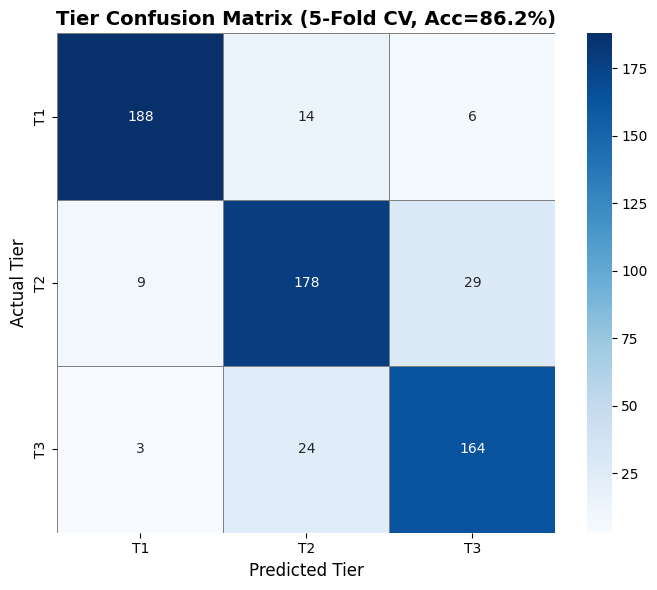

In [18]:
# ── 8.1 Confusion Matrix Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_order, yticklabels=tier_order,
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title(f'Tier Confusion Matrix (5-Fold CV, Acc={tier_m*100:.1f}%)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_v3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

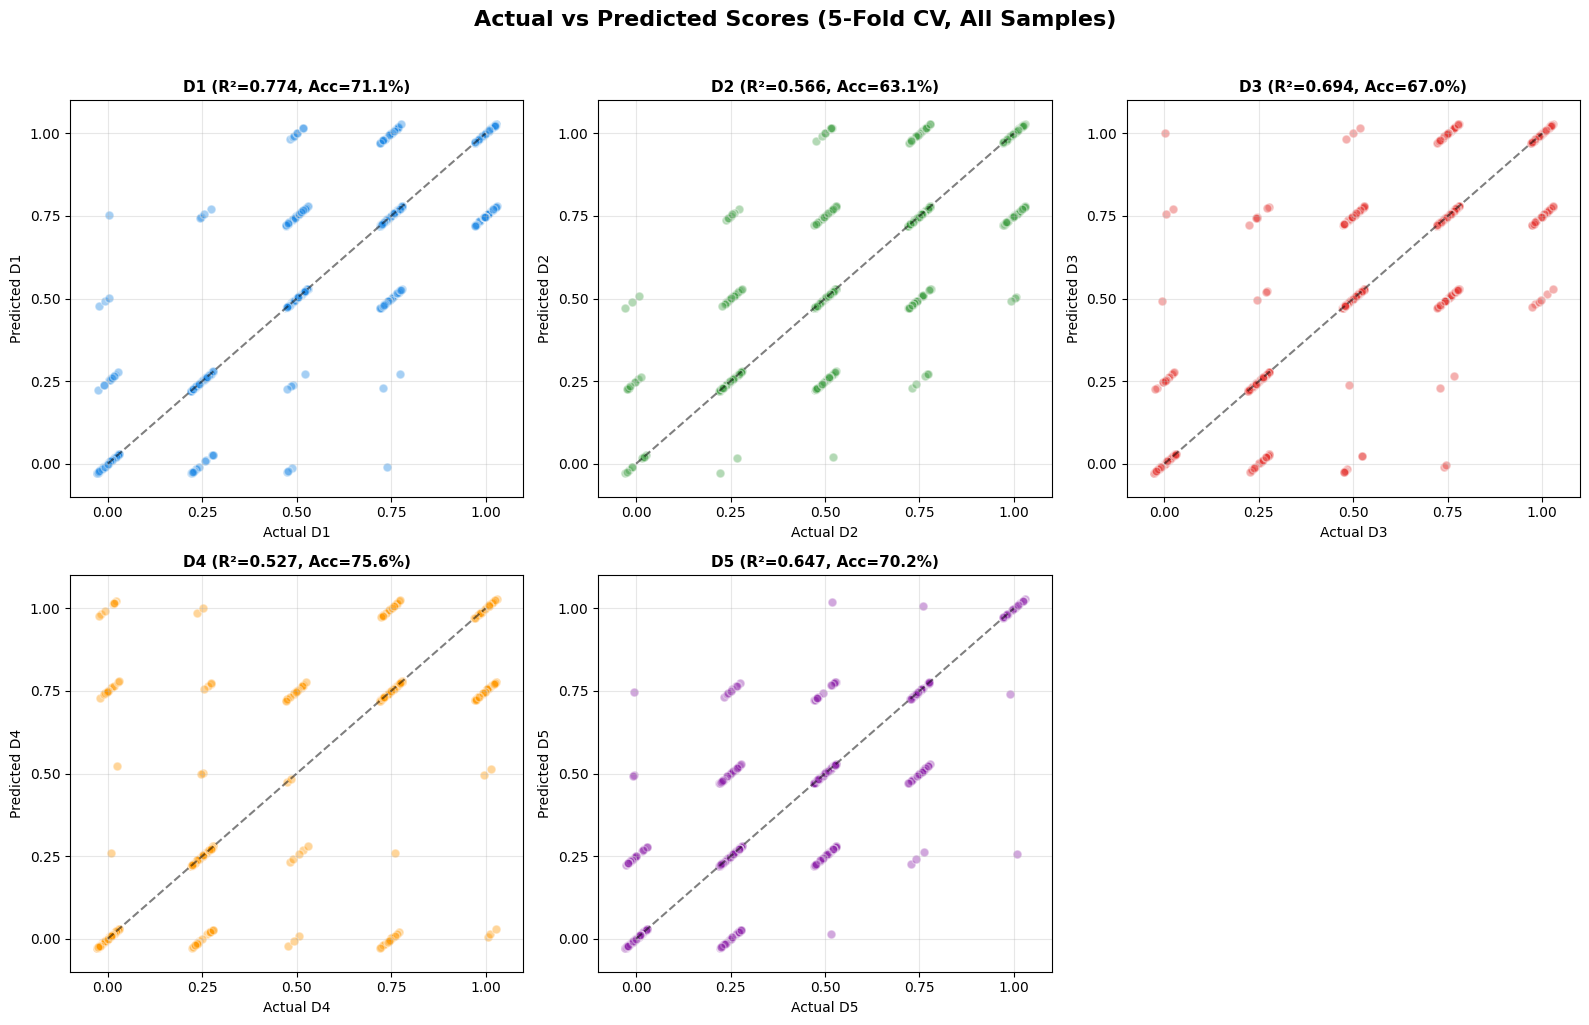

In [19]:
# ── 8.2 Actual vs Predicted Scatter Plots (all 5 dims) ───────────────────────
all_actual = np.vstack(all_actual_scores)
all_pred = np.vstack(all_pred_scores)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Actual vs Predicted Scores (5-Fold CV, All Samples)',
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#1E88E5', '#43A047', '#E53935', '#FF9800', '#8E24AA']
positions = [(0,0), (0,1), (0,2), (1,0), (1,1)]

for i, (dim, color, pos) in enumerate(zip(dim_names, colors, positions)):
    ax = axes[pos[0]][pos[1]]
    jitter = np.random.RandomState(42).uniform(-0.03, 0.03, size=len(all_actual))
    ax.scatter(all_actual[:, i] + jitter, all_pred[:, i] + jitter,
              alpha=0.4, color=color, edgecolors='white', s=40)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5)
    ax.set_xlabel(f'Actual {dim}', fontsize=10)
    ax.set_ylabel(f'Predicted {dim}', fontsize=10)
    ax.set_title(f'{dim} (R\u00b2={cv_results[dim]["R2"]:.3f}, Acc={cv_results[dim]["Acc"]:.1%})',
                fontsize=11, fontweight='bold')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('viz_v3_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

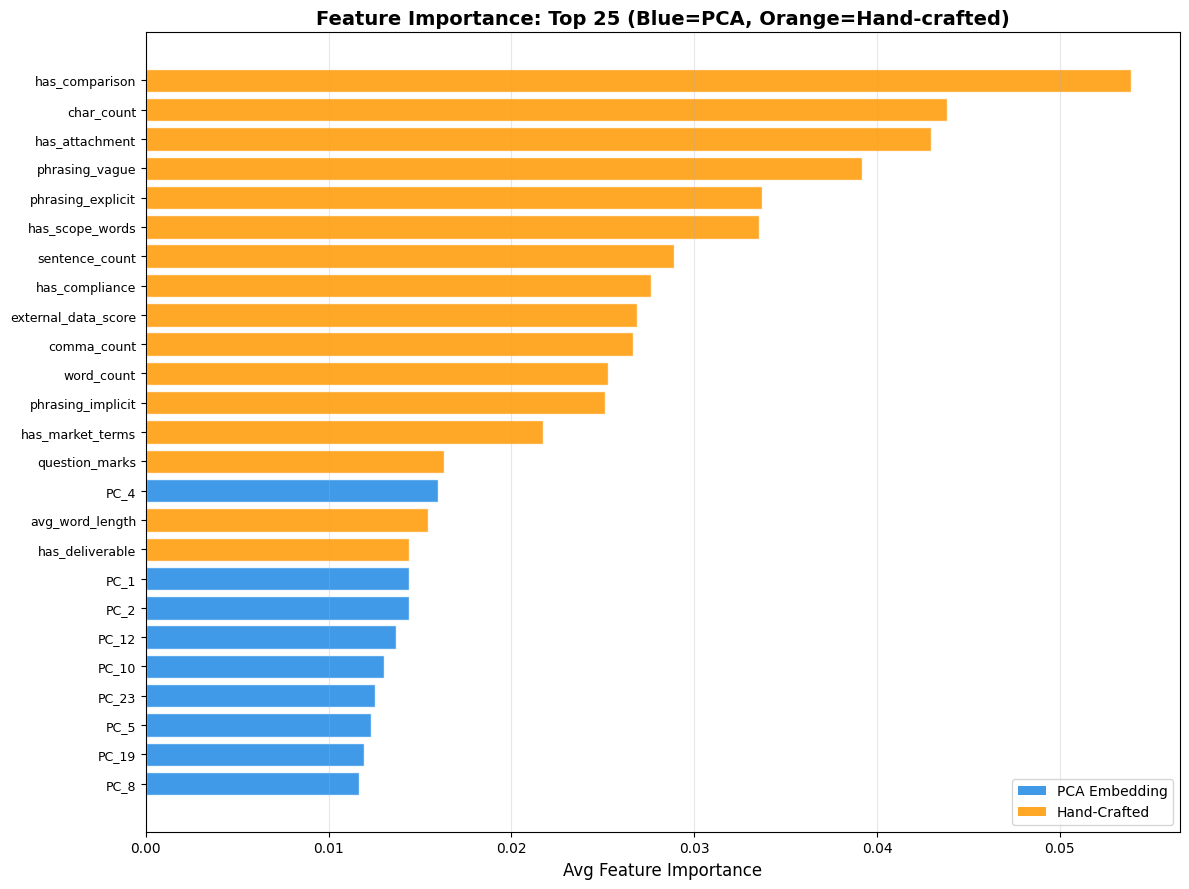


Hand-crafted feature importance ranking:
  has_comparison                 0.0539
  char_count                     0.0438
  has_attachment                 0.0430
  phrasing_vague                 0.0392
  phrasing_explicit              0.0337
  has_scope_words                0.0335
  sentence_count                 0.0289
  has_compliance                 0.0276
  external_data_score            0.0268
  comma_count                    0.0266
  word_count                     0.0253
  phrasing_implicit              0.0251
  has_market_terms               0.0218
  question_marks                 0.0163
  avg_word_length                0.0154
  has_deliverable                0.0144
  vendor_tool_count              0.0098
  has_time_reference             0.0097
  systems_mentioned              0.0094
  cloud_providers_mentioned      0.0089
  action_verb_count              0.0083
  stakeholder_mentions           0.0062
  risk_language                  0.0014
  has_cost_comparison            0.000

In [20]:
# ── 8.3 Feature Importance (Top 25) ──────────────────────────────────────────
importances = np.zeros(X_all_base_s.shape[1])
for est in final_multi_model.estimators_:
    # Importance is over augmented features; take only base features
    imp = est.feature_importances_[:-1]  # exclude tier_pred feature
    importances += imp
importances /= len(final_multi_model.estimators_)

# Top 25
top_n = min(25, len(importances))
top_idx = np.argsort(importances)[-top_n:][::-1]
top_vals = importances[top_idx]
top_labels = [feature_names[i] for i in top_idx]

bar_colors = ['#FF9800' if not lbl.startswith('PC_') else '#1E88E5' for lbl in top_labels]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(len(top_labels)), top_vals[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_labels)))
ax.set_yticklabels(top_labels[::-1], fontsize=9)
ax.set_xlabel('Avg Feature Importance', fontsize=12)
ax.set_title('Feature Importance: Top 25 (Blue=PCA, Orange=Hand-crafted)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#1E88E5', alpha=0.85, label='PCA Embedding'),
    Patch(facecolor='#FF9800', alpha=0.85, label='Hand-Crafted')
], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('viz_v3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print all hand-crafted importances
print("\nHand-crafted feature importance ranking:")
hc_start = N_PCA
hc_imps = importances[hc_start:]
for name, imp in sorted(zip(hc_feature_names, hc_imps), key=lambda x: -x[1]):
    print(f"  {name:<30s} {imp:.4f}")

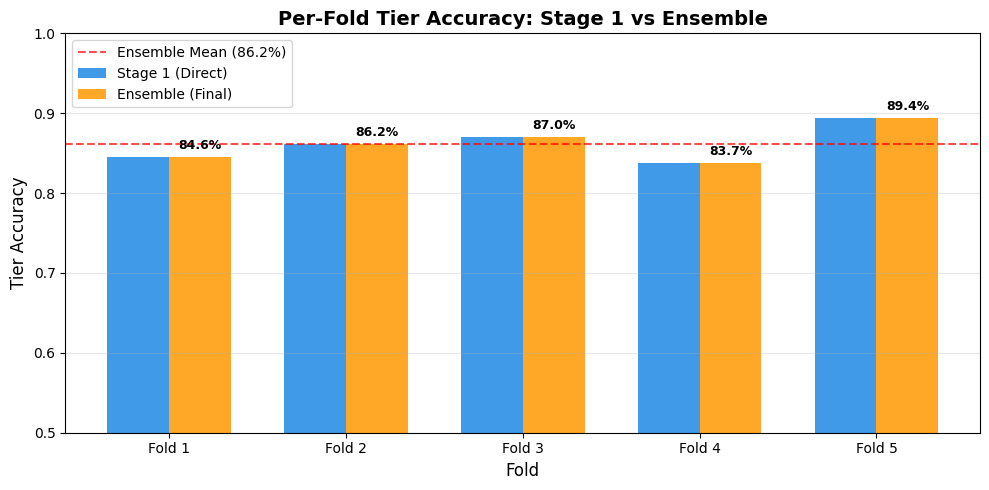

In [21]:
# ── 8.4 Per-Fold Tier Accuracy Bar Chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(N_FOLDS)
width = 0.35

ax.bar(x - width/2, fold_tier_s1_accs, width, label='Stage 1 (Direct)',
       color='#1E88E5', alpha=0.85)
ax.bar(x + width/2, fold_tier_accs, width, label='Ensemble (Final)',
       color='#FF9800', alpha=0.85)

ax.axhline(y=tier_m, color='red', linestyle='--', alpha=0.7,
           label=f'Ensemble Mean ({tier_m:.1%})')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Tier Accuracy', fontsize=12)
ax.set_title('Per-Fold Tier Accuracy: Stage 1 vs Ensemble',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for i in range(N_FOLDS):
    ax.text(x[i] + width/2, fold_tier_accs[i] + 0.01,
            f'{fold_tier_accs[i]:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_v3_fold_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Save Models

In [22]:
# ── Save all pipeline components ─────────────────────────────────────────────
joblib.dump(final_tier_clf, 'v3_tier_classifier.joblib')
joblib.dump(final_multi_model, 'v3_dimension_classifier.joblib')
joblib.dump(final_scaler, 'v3_scaler.joblib')
joblib.dump(final_pca, 'v3_pca.joblib')

print("Models saved:")
print("  \u2192 v3_tier_classifier.joblib")
print("  \u2192 v3_dimension_classifier.joblib")
print("  \u2192 v3_scaler.joblib")
print("  \u2192 v3_pca.joblib")

Models saved:
  → v3_tier_classifier.joblib
  → v3_dimension_classifier.joblib
  → v3_scaler.joblib
  → v3_pca.joblib


In [23]:
# ── FINAL SUMMARY ────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("     FINAL SUMMARY \u2014 Architecture 3 v3 (5-Fold CV Results)")
print("=" * 72)
print(f"{'Dim':<12} {'MAE':>8} {'RMSE':>8} {'R\u00b2':>8} {'Accuracy':>10}")
print("-" * 72)

for dim in dim_names:
    r = cv_results[dim]
    print(f"{dim:<12} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f} {r['Acc']:>9.2%}")

print("-" * 72)
print(f"{'Tier (S1)':<12} {'':<8} {'':<8} {'':<8} {s1_m:>9.2%}")
print(f"{'Tier (Ens)':<12} {'':<8} {'':<8} {'':<8} {tier_m:>9.2%}")
print("=" * 72)
print(f"\nImprovements applied:")
print(f"  \u2713 Augmented dataset: {len(df)} prompts (was 470)")
print(f"  \u2713 D4 via ML (was rule engine)")
print(f"  \u2713 Two-stage prediction (tier-aware)")
print(f"  \u2713 5-fold cross-validation")
print(f"  \u2713 {len(hc_feature_names)} hand-crafted features (was 18)")
print(f"  \u2713 PCA: {N_PCA} components (was 50)")
print(f"  \u2713 Regularized XGBoost (L1={XGB_PARAMS['reg_alpha']}, L2={XGB_PARAMS['reg_lambda']})")
print(f"  \u2713 Total features: {X_all_base_s.shape[1]} + 1 (tier) = {X_all_base_s.shape[1]+1}")
print(f"  \u2713 Feature-to-sample ratio: 1:{X_all_base_s.shape[0]/X_all_base_s.shape[1]:.1f}")


     FINAL SUMMARY — Architecture 3 v3 (5-Fold CV Results)
Dim               MAE     RMSE       R²   Accuracy
------------------------------------------------------------------------
D1             0.0817   0.1596   0.7741    71.06%
D2             0.1033   0.1761   0.5662    63.09%
D3             0.0972   0.1816   0.6939    66.99%
D4             0.1053   0.2477   0.5269    75.61%
D5             0.0821   0.1573   0.6469    70.24%
------------------------------------------------------------------------
Tier (S1)                                  86.18%
Tier (Ens)                                 86.18%

Improvements applied:
  ✓ Augmented dataset: 615 prompts (was 470)
  ✓ D4 via ML (was rule engine)
  ✓ Two-stage prediction (tier-aware)
  ✓ 5-fold cross-validation
  ✓ 24 hand-crafted features (was 18)
  ✓ PCA: 30 components (was 50)
  ✓ Regularized XGBoost (L1=0.1, L2=1.5)
  ✓ Total features: 54 + 1 (tier) = 55
  ✓ Feature-to-sample ratio: 1:11.4


In [24]:
# ── Verify saved models ──────────────────────────────────────────────────────
l_tier = joblib.load('v3_tier_classifier.joblib')
l_dim = joblib.load('v3_dimension_classifier.joblib')
l_scaler = joblib.load('v3_scaler.joblib')
l_pca = joblib.load('v3_pca.joblib')

# Quick verification
v_emb = embed_model.encode(["test prompt"])
v_pca = l_pca.transform(v_emb)
v_hc = extract_handcrafted_features("test prompt")
v_combined = np.hstack([v_pca, np.array([list(v_hc.values())])])
v_scaled = l_scaler.transform(v_combined)
v_tier = l_tier.predict(v_scaled)
v_aug = np.hstack([v_scaled, v_tier.reshape(-1, 1)])
v_pred = l_dim.predict(v_aug)
v_scores = [CLASS_TO_SCORE[c] for c in v_pred[0]]

print(f"Model verification: D1={v_scores[0]}, D2={v_scores[1]}, "
      f"D3={v_scores[2]}, D4={v_scores[3]}, D5={v_scores[4]}")
print(f"Tier: {INT_TO_TIER[v_tier[0]]}")
print(f"\n\u2705 Architecture 3 v3 pipeline complete!")

Model verification: D1=0.0, D2=0.25, D3=0.0, D4=0.0, D5=0.0
Tier: T1

✅ Architecture 3 v3 pipeline complete!
